In [2]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, train_cnn_lstm_baseline, plot_loss_vs_epoch, train_multiscale_cnn_lstm, train_cnn_lstm_attention, evaluate_cnn_lstm_vitaldb

In [4]:
WINDOW_SIZE = 1000
STEP_SIZE = 500

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_50%overlap/vitaldb_checkpoints"

X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=WINDOW_SIZE,
    STEP_SIZE=STEP_SIZE
)

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [02:48<00:00, 57.08it/s]


Skipped recordings: 103


100%|██████████| 1200/1200 [00:20<00:00, 57.52it/s]


Skipped recordings: 8


100%|██████████| 1200/1200 [00:21<00:00, 55.76it/s]


Skipped recordings: 9


In [5]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

X_train shape: (517036, 1, 1000), y_train shape: (517036, 2)
X_val shape: (65284, 1, 1000), y_val shape: (65284, 2)


Device: cuda
X_train: torch.Size([517036, 1, 1000])
y_train: torch.Size([517036, 2])
X_val: torch.Size([65284, 1, 1000])
y_val: torch.Size([65284, 2])
X_test: torch.Size([65554, 1, 1000])
y_test: torch.Size([65554, 2])
Epoch 01/50 | Train Loss: 758.5524 | Val Loss: 224.2599 | Train SBP RMSE: 35.012 | Train DBP RMSE: 17.066 | Val SBP RMSE: 18.778 | Val DBP RMSE: 9.792 | LR: 1.00e-03
Epoch 02/50 | Train Loss: 198.8391 | Val Loss: 199.8689 | Train SBP RMSE: 17.560 | Train DBP RMSE: 9.451 | Val SBP RMSE: 17.589 | Val DBP RMSE: 9.506 | LR: 1.00e-03
Epoch 03/50 | Train Loss: 172.7737 | Val Loss: 197.7493 | Train SBP RMSE: 16.299 | Train DBP RMSE: 8.937 | Val SBP RMSE: 17.638 | Val DBP RMSE: 9.186 | LR: 1.00e-03
Epoch 04/50 | Train Loss: 156.8074 | Val Loss: 195.4036 | Train SBP RMSE: 15.434 | Train DBP RMSE: 8.683 | Val SBP RMSE: 17.584 | Val DBP RMSE: 9.035 | LR: 1.00e-03
Epoch 05/50 | Train Loss: 144.6896 | Val Loss: 191.0895 | Train SBP RMSE: 14.740 | Train DBP RMSE: 8.491 | Val SBP RMSE:

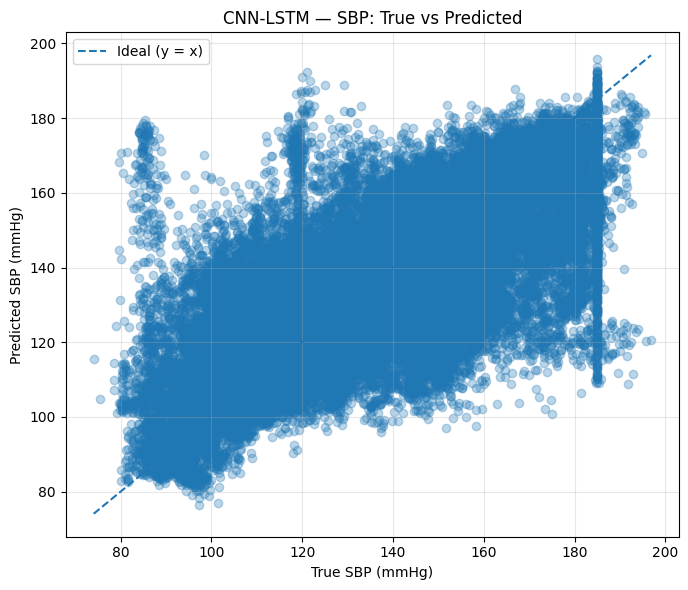

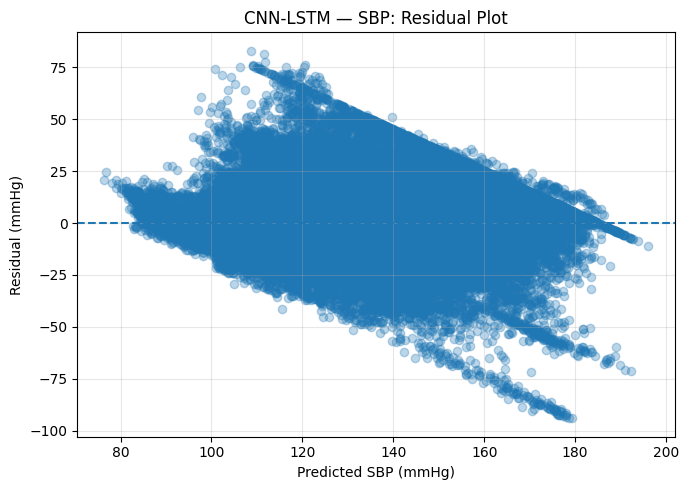

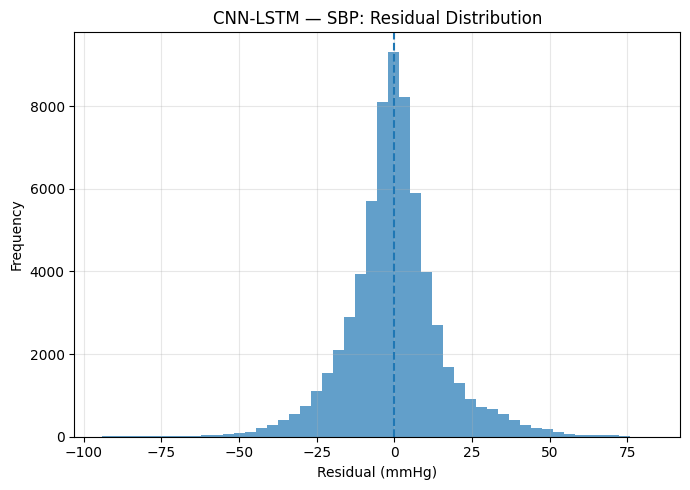

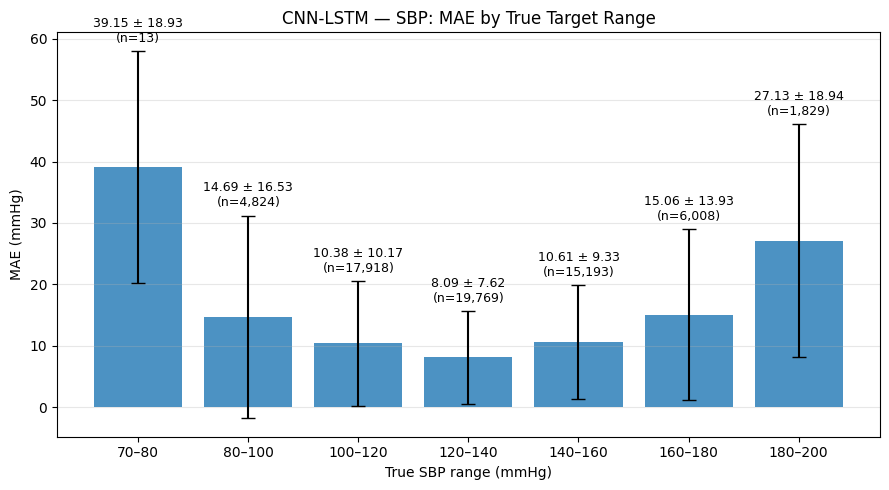

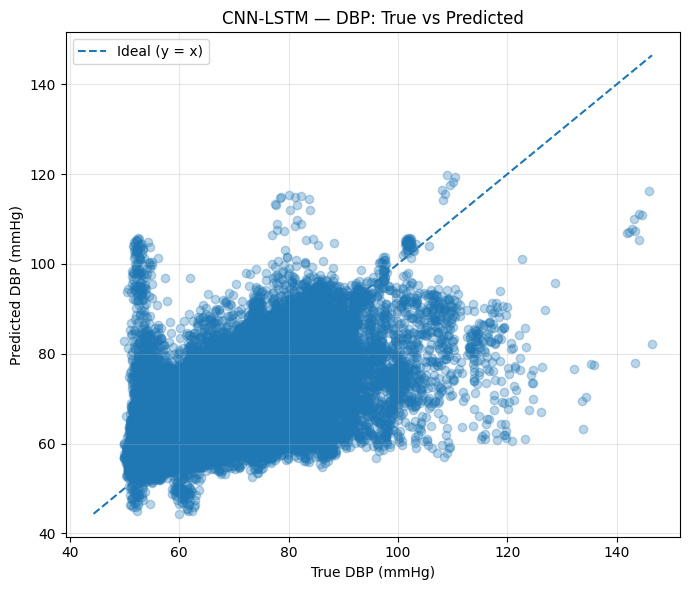

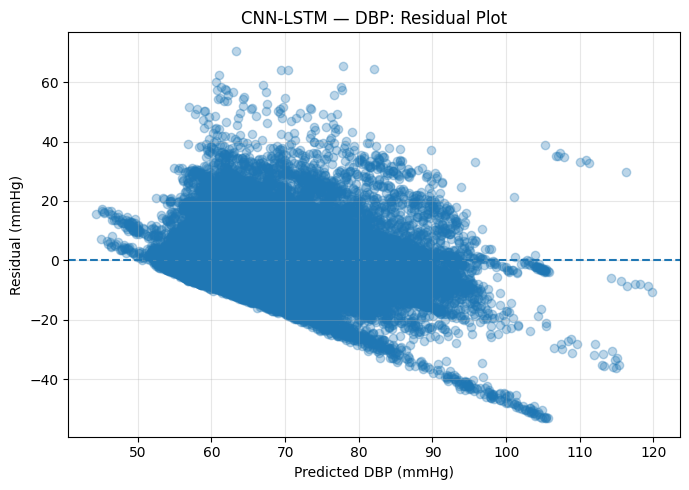

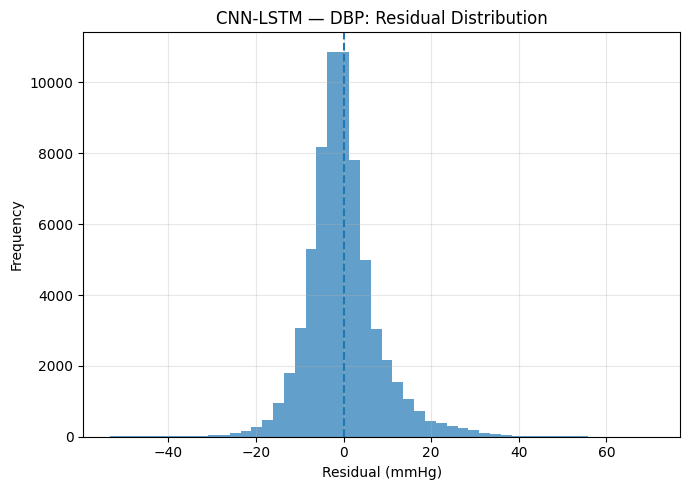

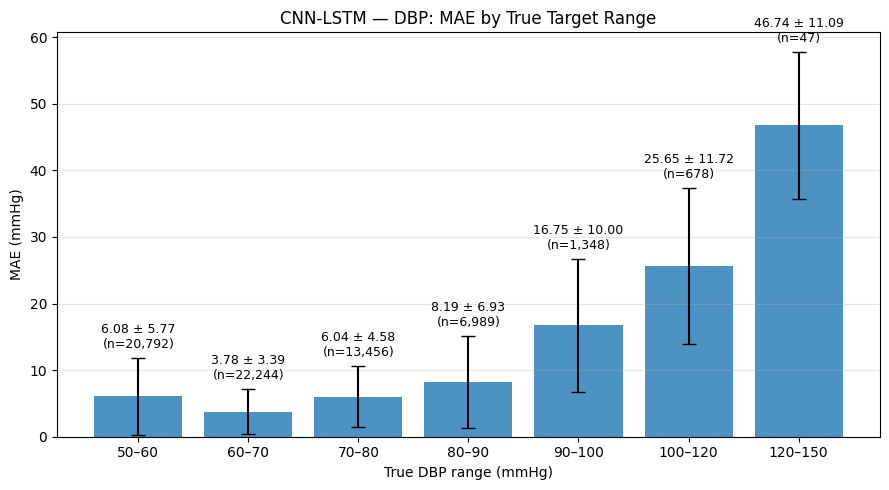

In [6]:
model_cnn_lstm, results_cnn_lstm = train_cnn_lstm_baseline(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    batch_size=256,
    epochs=50,
    lr=1e-3,
    patience=10
)

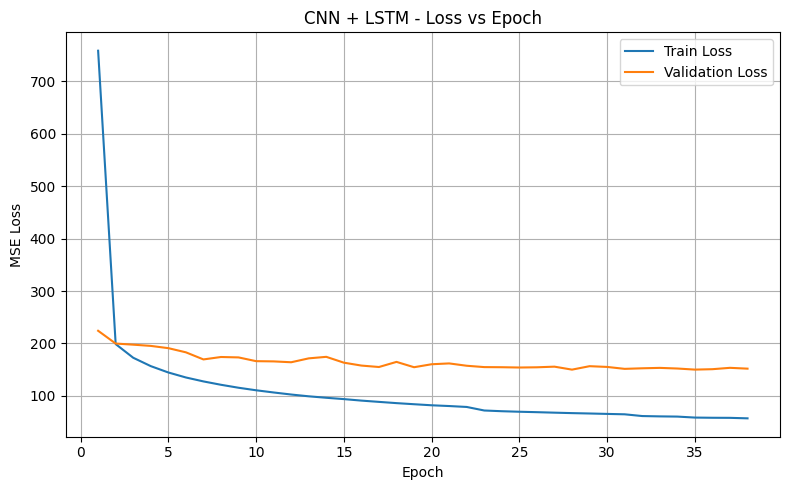

In [7]:
plot_loss_vs_epoch(
    results_cnn_lstm["history"],
    model_name="CNN + LSTM"
)

Number of VitalDB cases: 1962


CNN-LSTM VitalDB prediction: 100%|██████████| 1962/1962 [04:32<00:00,  7.20case/s]



CNN-LSTM
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 25.3037
MSE : 640.2792
R²  : -0.5010
MAE : 20.1148

DBP
RMSE: 14.3624
MSE : 206.2774
R²  : -0.2752
MAE : 11.3381


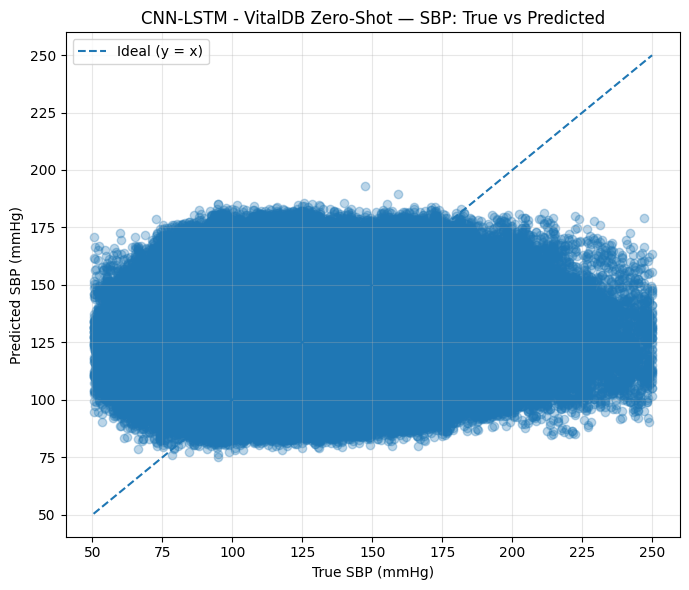

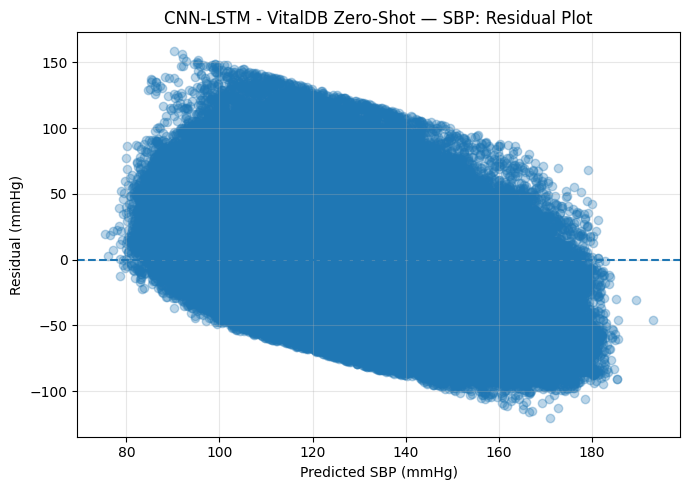

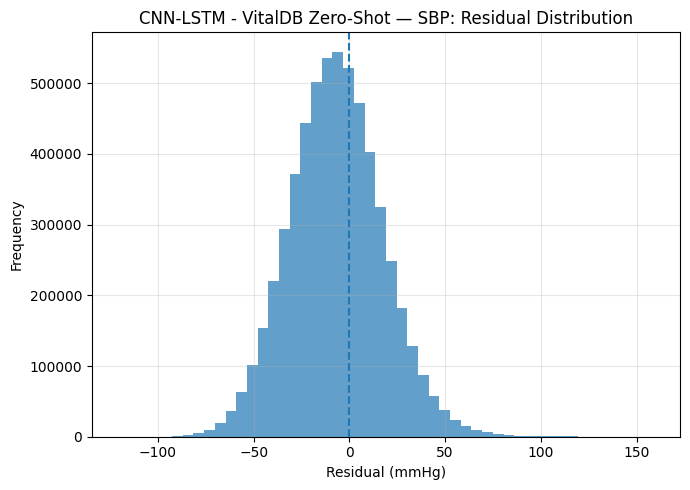

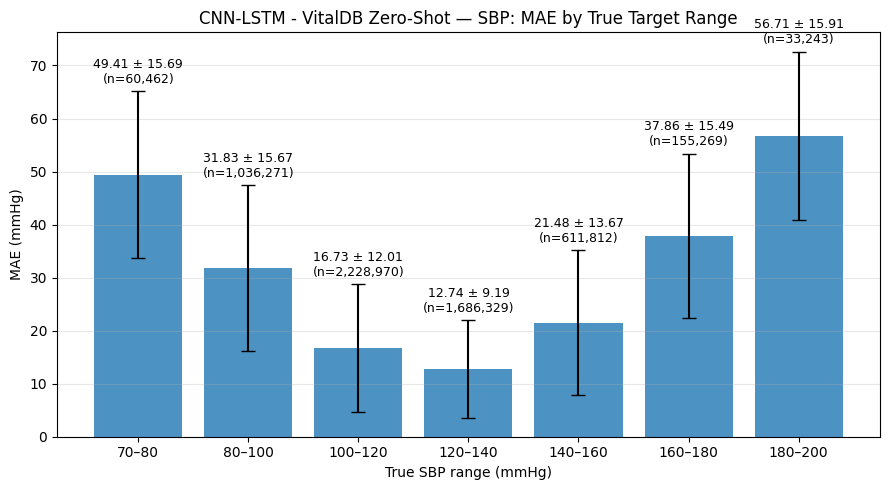

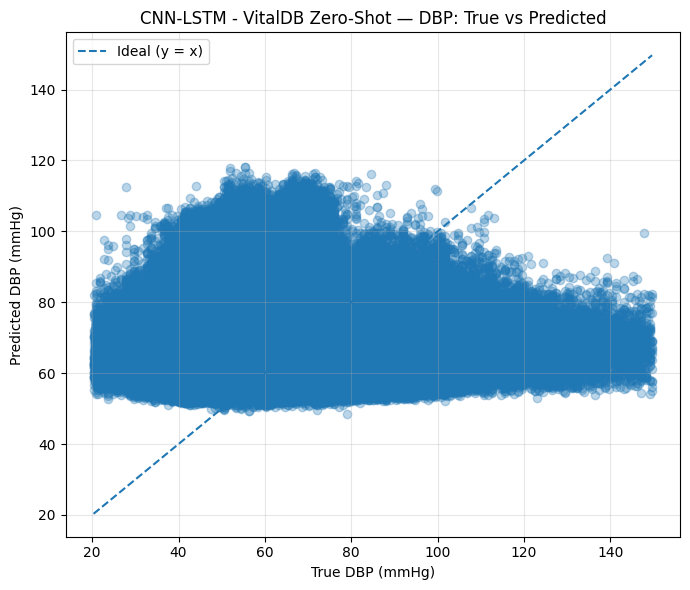

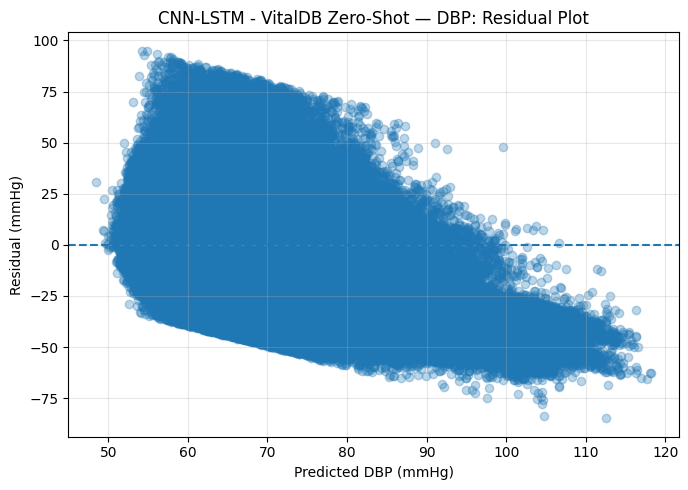

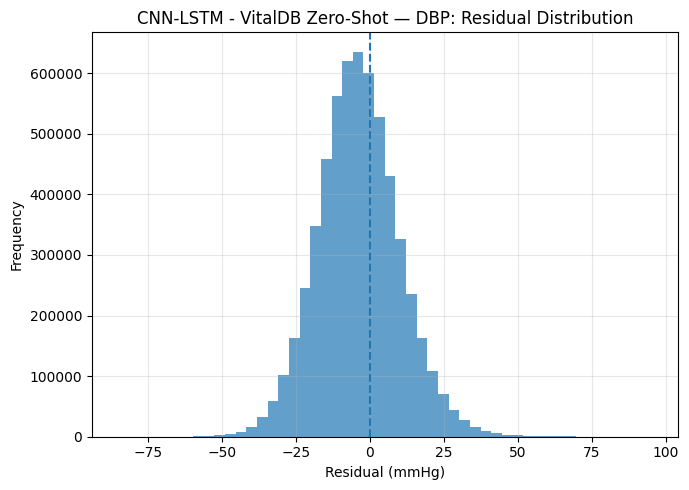

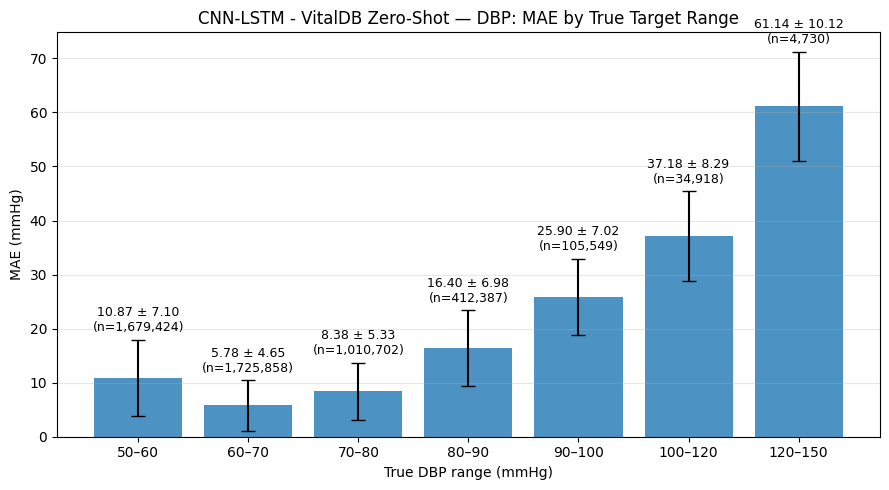

In [8]:
results_cnn_lstm_vitaldb = evaluate_cnn_lstm_vitaldb( model=model_cnn_lstm, base_dir=BASE_DIR, batch_size=256 )

####

Device: cuda
X_train: torch.Size([517036, 1, 1000])
y_train: torch.Size([517036, 2])
X_val: torch.Size([65284, 1, 1000])
y_val: torch.Size([65284, 2])
X_test: torch.Size([65554, 1, 1000])
y_test: torch.Size([65554, 2])
Epoch 01/50 | Train Loss: 692.1241 | Val Loss: 230.1046 | Train SBP RMSE: 33.190 | Train DBP RMSE: 16.813 | Val SBP RMSE: 18.806 | Val DBP RMSE: 10.322 | LR: 1.00e-03
Epoch 02/50 | Train Loss: 207.9350 | Val Loss: 202.0551 | Train SBP RMSE: 17.873 | Train DBP RMSE: 9.820 | Val SBP RMSE: 17.653 | Val DBP RMSE: 9.617 | LR: 1.00e-03
Epoch 03/50 | Train Loss: 179.3621 | Val Loss: 187.9908 | Train SBP RMSE: 16.612 | Train DBP RMSE: 9.098 | Val SBP RMSE: 17.111 | Val DBP RMSE: 9.122 | LR: 1.00e-03
Epoch 04/50 | Train Loss: 157.0294 | Val Loss: 178.9343 | Train SBP RMSE: 15.433 | Train DBP RMSE: 8.711 | Val SBP RMSE: 16.675 | Val DBP RMSE: 8.933 | LR: 1.00e-03
Epoch 05/50 | Train Loss: 141.7393 | Val Loss: 172.0987 | Train SBP RMSE: 14.566 | Train DBP RMSE: 8.445 | Val SBP RMSE

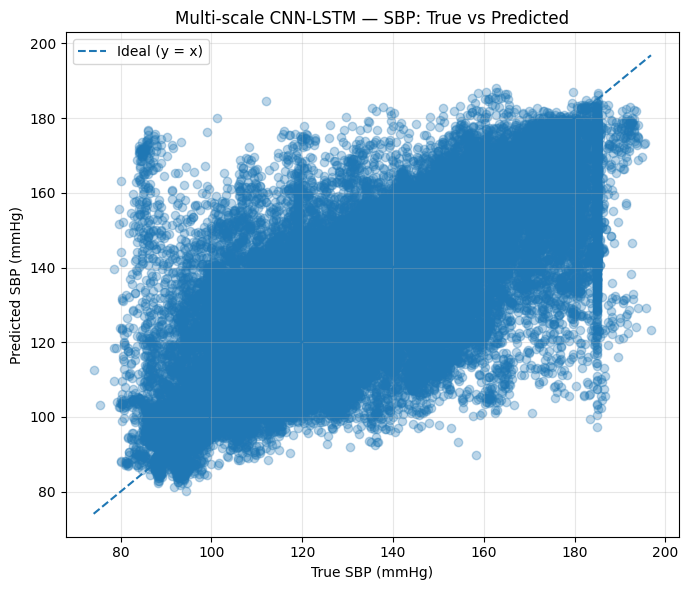

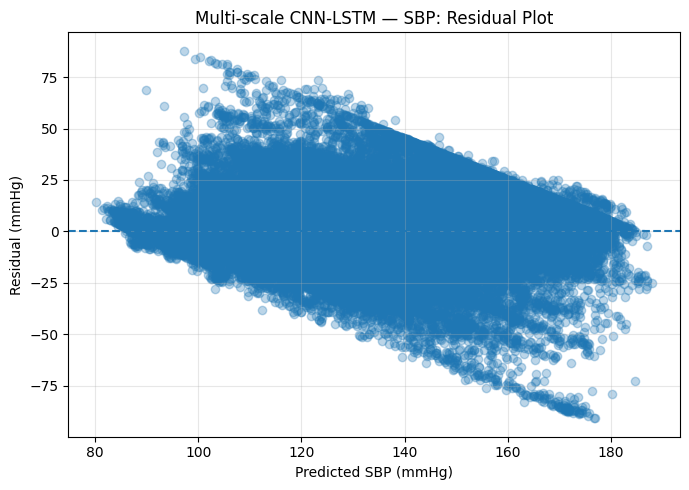

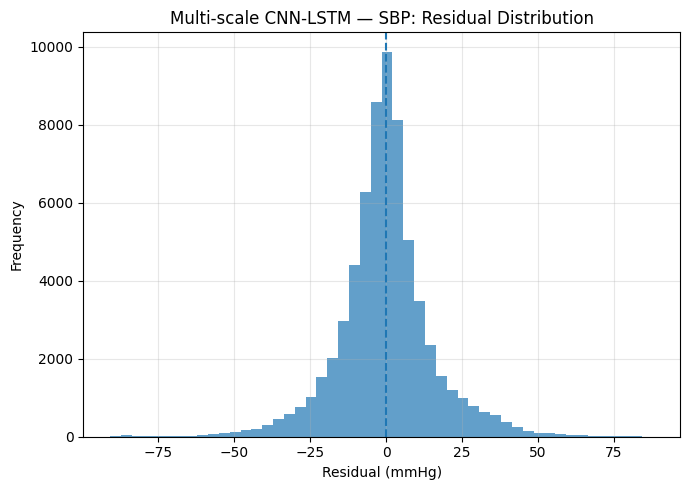

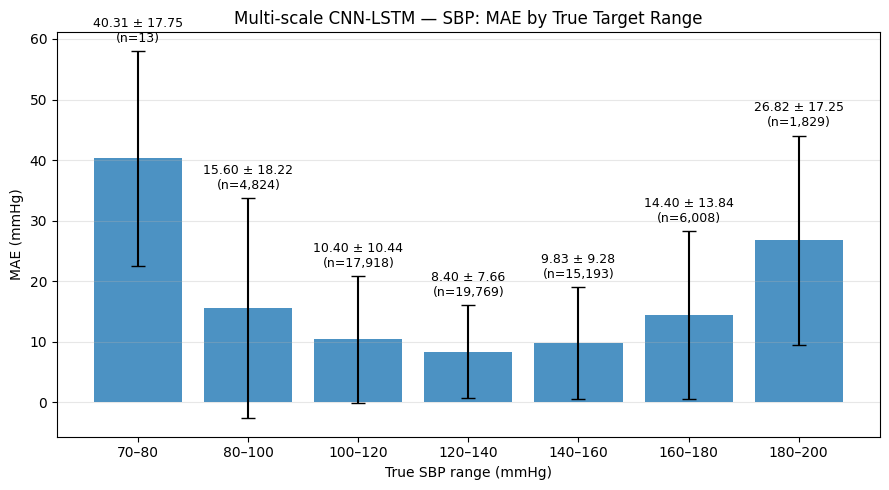

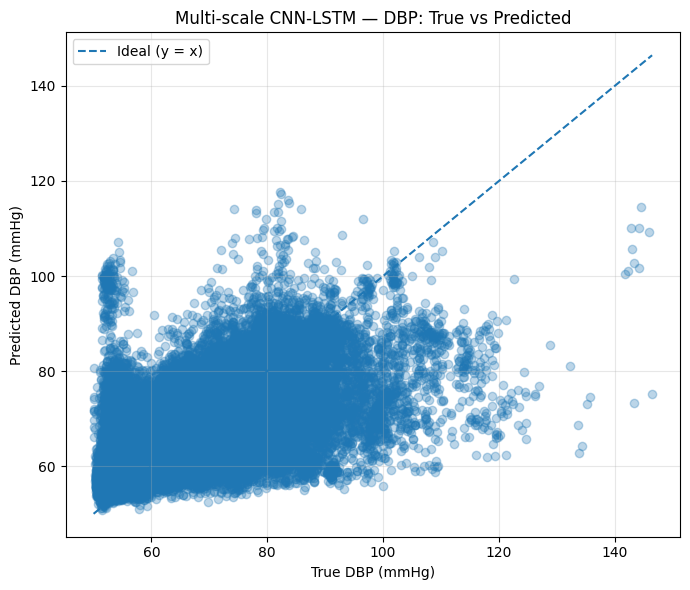

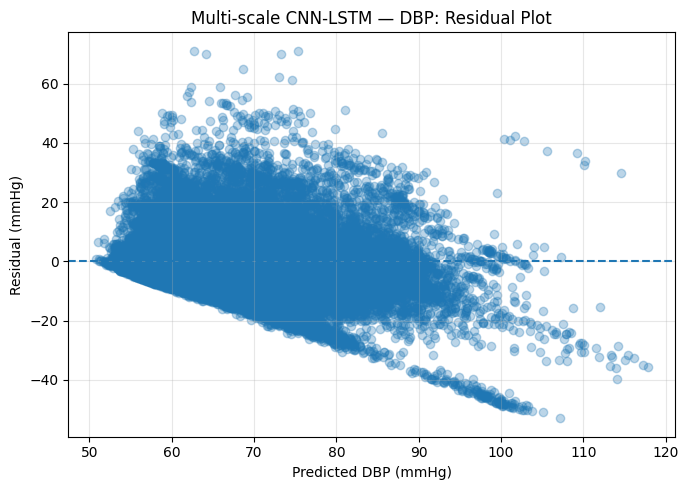

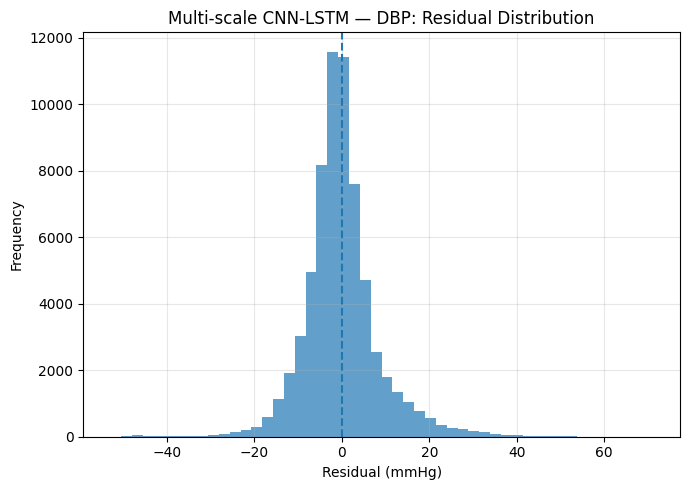

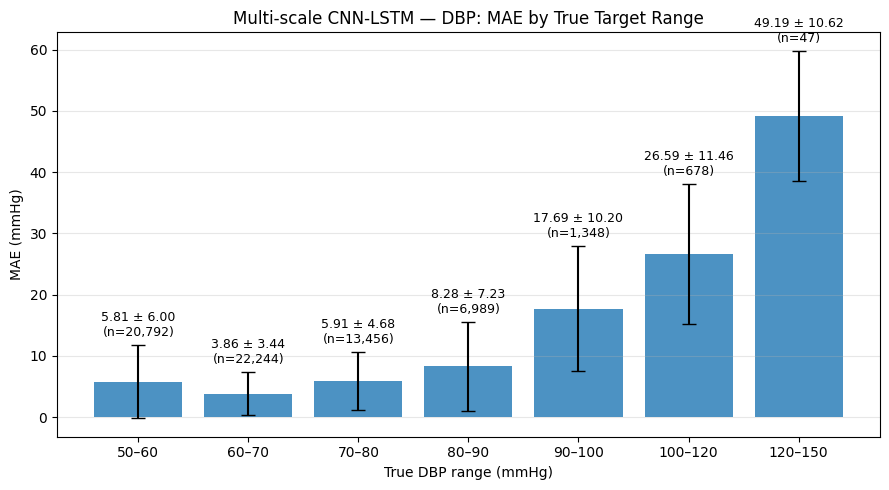

In [9]:
model_multiscale, results_multiscale = train_multiscale_cnn_lstm( 
    X_train=X_train, 
    y_train=y_train, 
    X_val=X_val, 
    y_val=y_val, 
    X_test=X_test,
     y_test=y_test, 
     batch_size=256, 
     epochs=50, 
     lr=1e-3, 
     patience=10 )


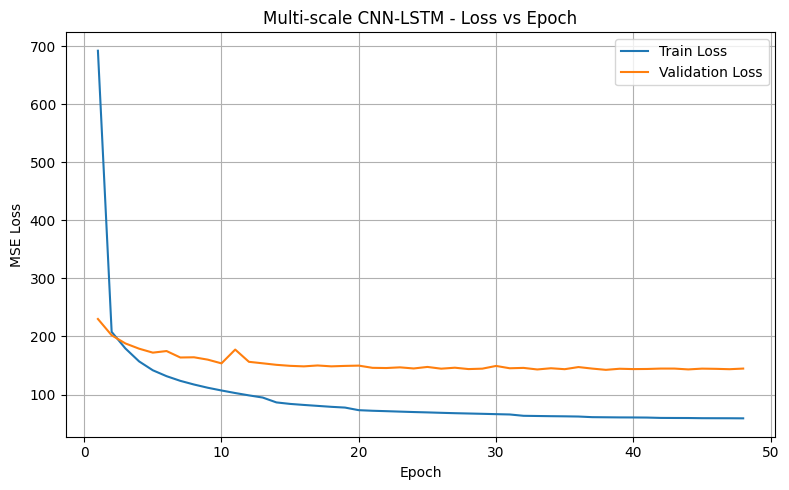

In [10]:
plot_loss_vs_epoch( results_multiscale["history"], model_name="Multi-scale CNN-LSTM" )

Number of VitalDB cases: 1962


CNN-LSTM VitalDB prediction: 100%|██████████| 1962/1962 [03:18<00:00,  9.91case/s]



CNN-LSTM
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 26.3644
MSE : 695.0803
R²  : -0.6295
MAE : 21.0034

DBP
RMSE: 14.7928
MSE : 218.8269
R²  : -0.3528
MAE : 11.6822


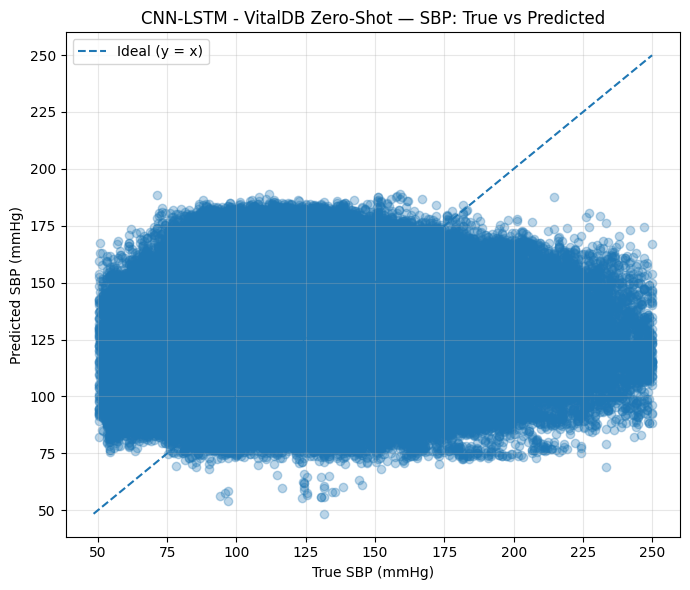

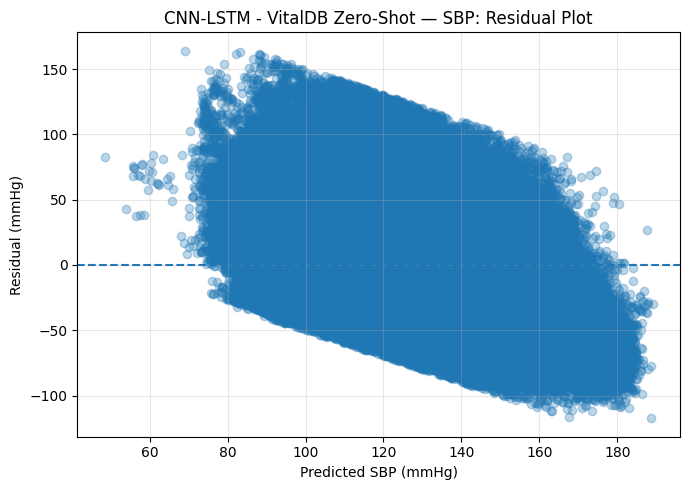

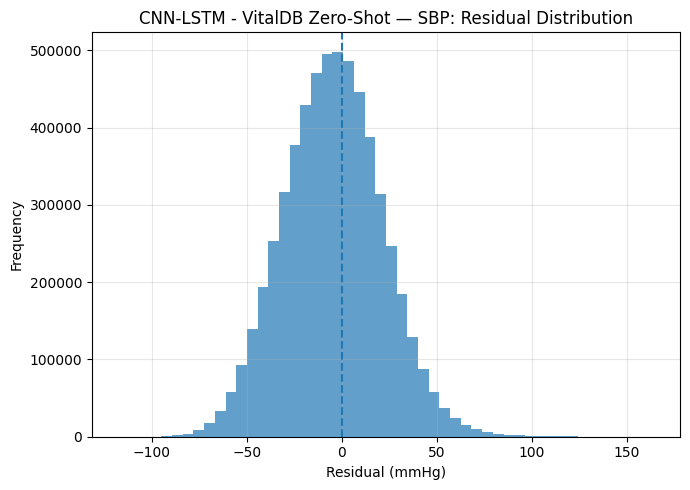

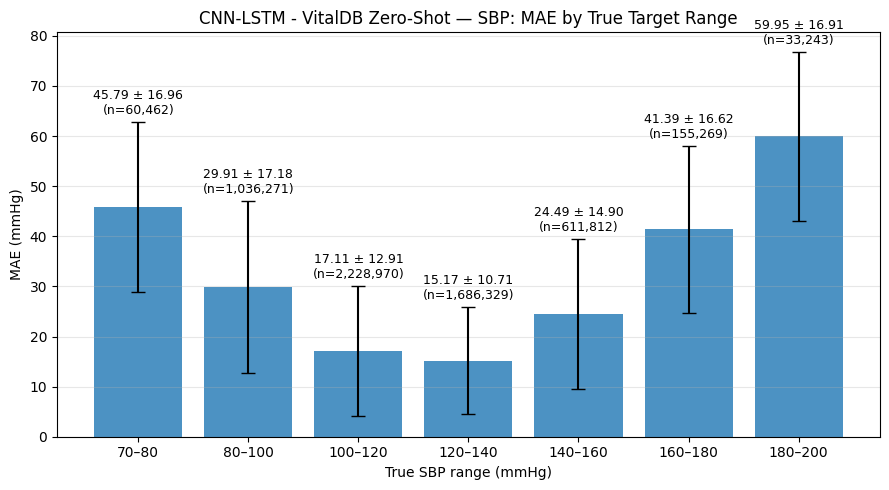

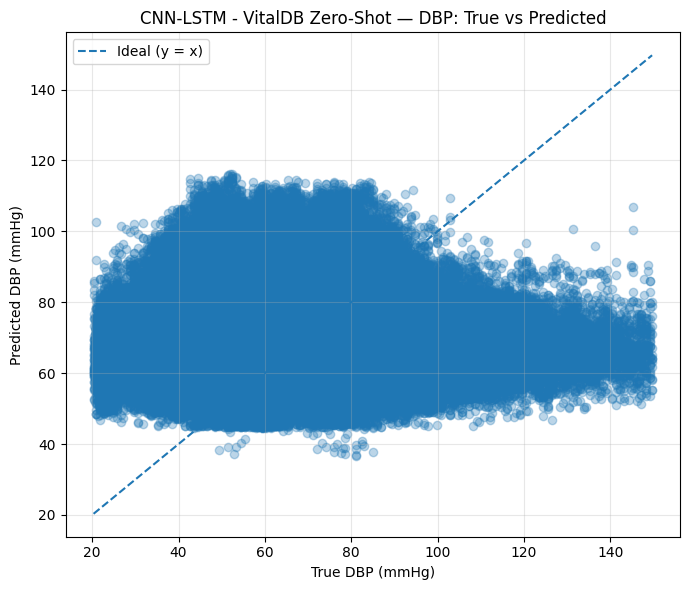

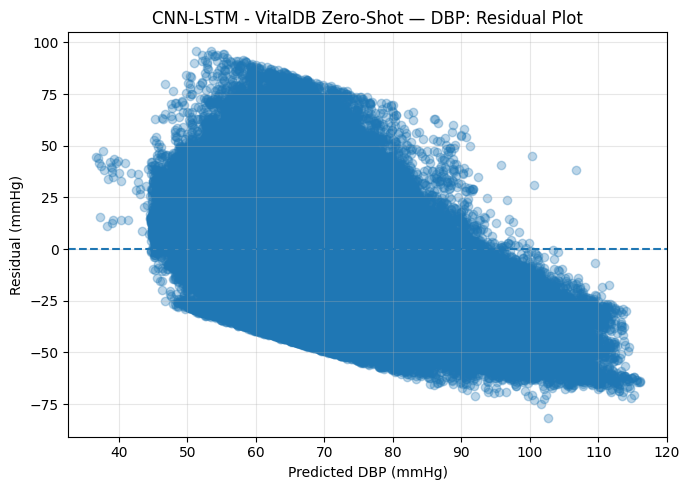

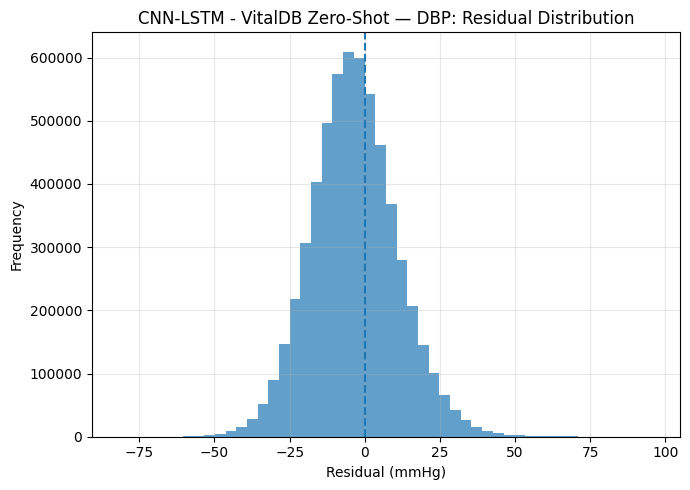

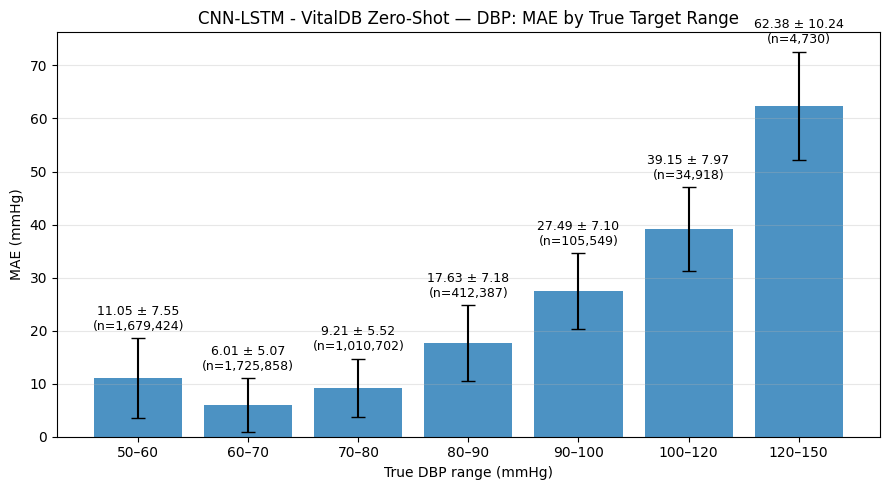

In [11]:
results_multiscale_vitaldb = evaluate_cnn_lstm_vitaldb( model=model_multiscale, base_dir=BASE_DIR, batch_size=256 )

####

In [12]:
model_attention, results_attention = train_cnn_lstm_attention(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    batch_size=256,
    epochs=50,
    lr=1e-3,
    patience=10
)

Epoch 01/50 | Train Loss: 841.2274 | Val Loss: 222.5635 | Train RMSE SBP/DBP: 36.70/18.33 | Val RMSE SBP/DBP: 18.28/10.54
Epoch 02/50 | Train Loss: 291.8497 | Val Loss: 392.5414 | Train RMSE SBP/DBP: 21.18/11.62 | Val RMSE SBP/DBP: 24.61/13.39
Epoch 03/50 | Train Loss: 260.1937 | Val Loss: 191.1508 | Train RMSE SBP/DBP: 19.87/11.20 | Val RMSE SBP/DBP: 16.79/10.02
Epoch 04/50 | Train Loss: 171.5284 | Val Loss: 213.1622 | Train RMSE SBP/DBP: 15.94/9.44 | Val RMSE SBP/DBP: 17.96/10.19
Epoch 05/50 | Train Loss: 135.5437 | Val Loss: 211.1165 | Train RMSE SBP/DBP: 14.12/8.47 | Val RMSE SBP/DBP: 18.01/9.89
Epoch 06/50 | Train Loss: 120.0919 | Val Loss: 213.2442 | Train RMSE SBP/DBP: 13.26/8.03 | Val RMSE SBP/DBP: 17.92/10.26
Epoch 07/50 | Train Loss: 109.7399 | Val Loss: 201.3821 | Train RMSE SBP/DBP: 12.65/7.72 | Val RMSE SBP/DBP: 17.42/9.96
Epoch 08/50 | Train Loss: 96.5178 | Val Loss: 196.6128 | Train RMSE SBP/DBP: 11.78/7.37 | Val RMSE SBP/DBP: 17.40/9.50
Epoch 09/50 | Train Loss: 91.7451

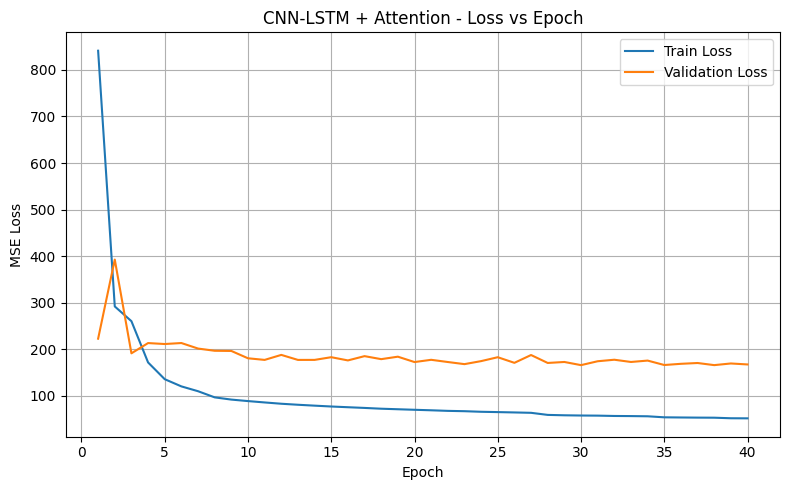

In [13]:
plot_loss_vs_epoch(
    results_attention["history"],
    model_name="CNN-LSTM + Attention"
)

Number of VitalDB cases: 1962


CNN-LSTM VitalDB prediction: 100%|██████████| 1962/1962 [02:44<00:00, 11.94case/s]



CNN-LSTM
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 28.3007
MSE : 800.9315
R²  : -0.8776
MAE : 22.9192

DBP
RMSE: 17.3827
MSE : 302.1597
R²  : -0.8680
MAE : 13.5865


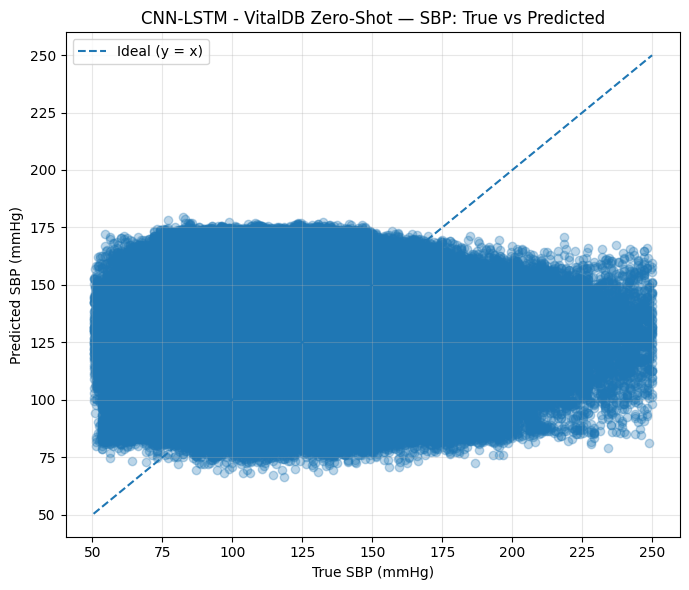

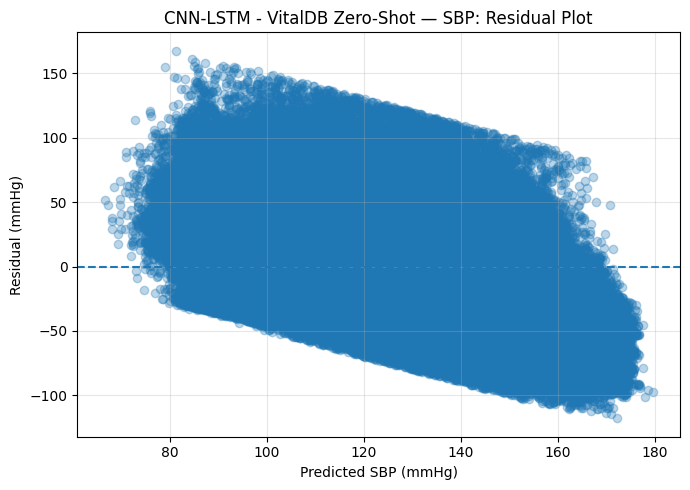

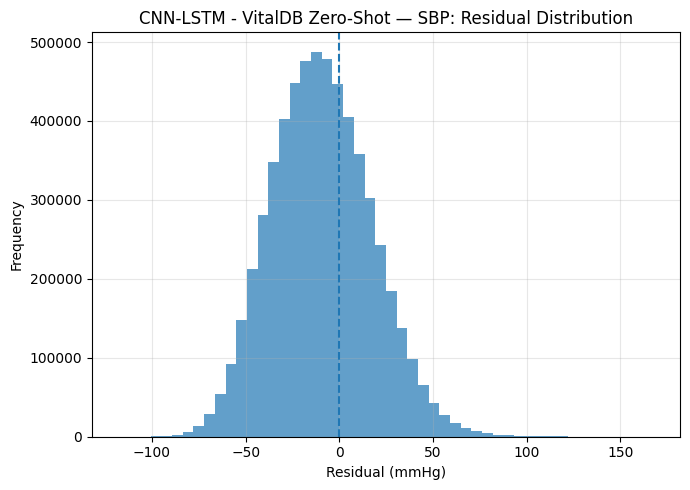

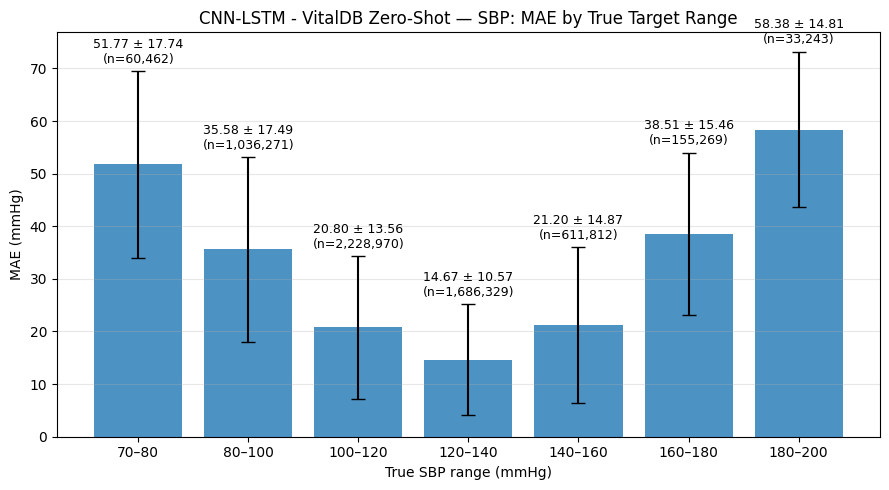

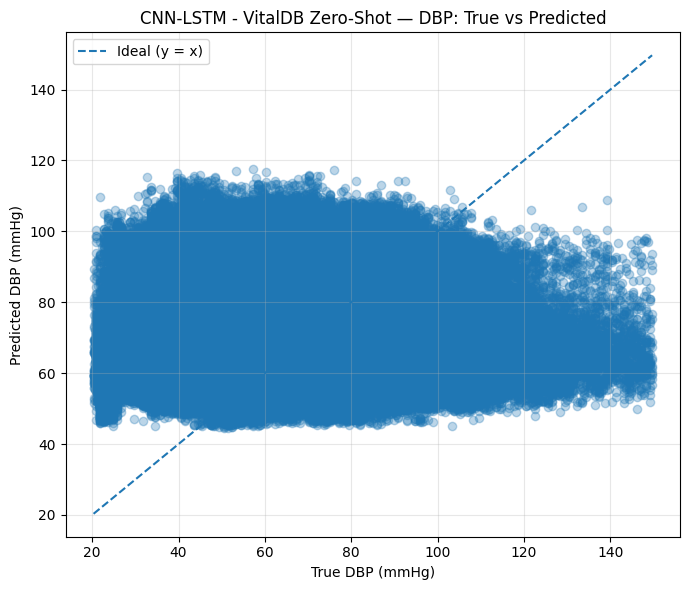

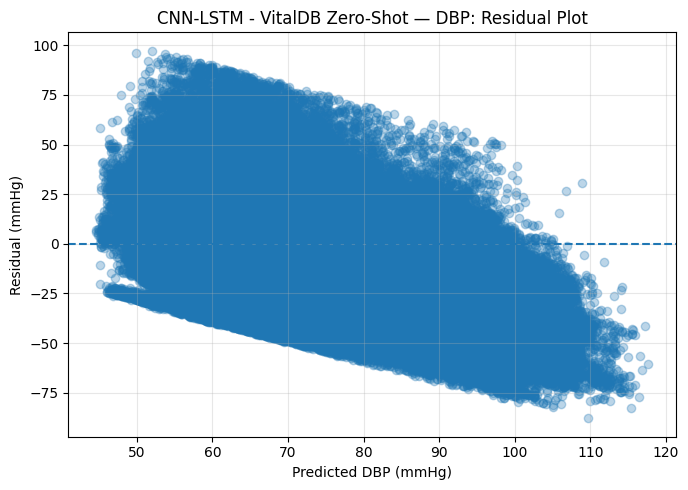

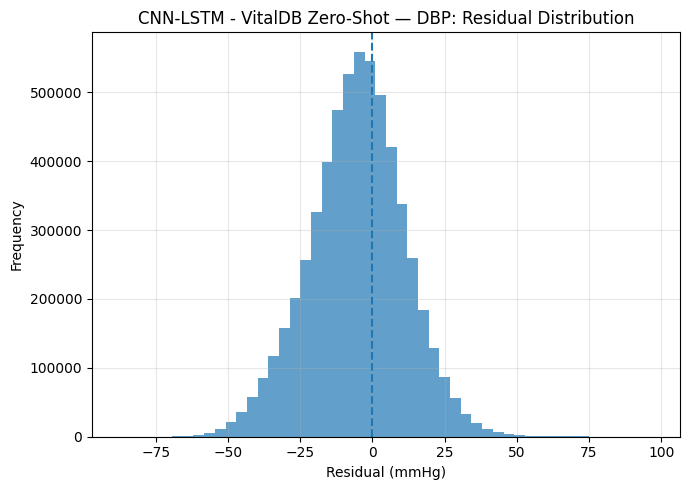

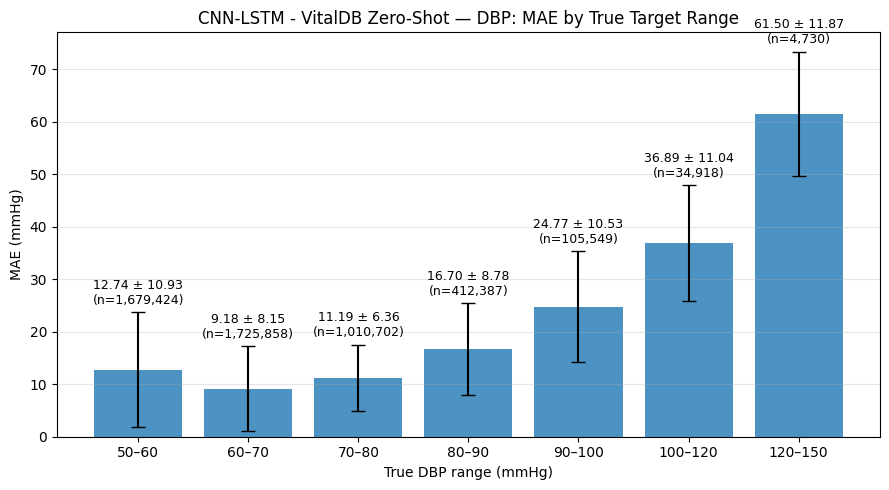

In [14]:

results_attention_vitaldb = evaluate_cnn_lstm_vitaldb(
    model=model_attention,
    base_dir=BASE_DIR,
    batch_size=256
)